In [ ]:
import psutil

ram = psutil.virtual_memory()
print(f"Total RAM: {ram.total / (1024**3):.2f} GB")
print(f"Available RAM: {ram.available / (1024**3):.2f} GB")

Total RAM: 172.95 GB
Available RAM: 170.06 GB


In [ ]:
# install requirements for v6 Tpu
!pip install opencv-python
!pip install tensorflow
!pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 87.1 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 130.8 kB/s eta 0:00:00


In [ ]:
import zipfile
import os
import cv2
import numpy as np
import pandas as pd
import random
import tensorflow as tf
from skimage.metrics import structural_similarity as ssim
#from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, Dropout, TimeDistributed, GlobalAveragePooling2D, GRU, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Nadam
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, f1_score


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
# GLOBAL CONSTANTS
NUM_FRAMES = 40 #4
MIN_FRAMES = 120
max_frames = 120
IMAGE_HEIGHT, IMAGE_WIDTH = 224, 224
# SSIM_THRESHOLD = 0.80
# NUM_SHUFFLES = 6 #2 #6
SEED = 42

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import numpy as np

# Load X_prep_segments_40.npy from Drive
X = np.load('/content/drive/My Drive/Colab Notebooks_videoAnalytics/optimal_seg/X_prep_segments_40.npy')

# Print shape of X
print("Shape of X_prep:", X.shape)

# Load y_labels_segments_40.npy from Drive
y = np.load('/content/drive/My Drive/Colab Notebooks_videoAnalytics/optimal_seg/y_labels_segments_40.npy')

# Print shape of y
print("Shape of y_labels:", y.shape)

Mounted at /content/drive
Shape of X_prep: (1351, 40, 224, 224, 3)
Shape of y_labels: (1351,)


In [ ]:
print(X)


[[[[[0.33333337 0.33333337 0.33333337]
    [0.3411765  0.3411765  0.3411765 ]
    [0.33333337 0.33333337 0.33333337]
    ...
    [0.38823533 0.36470592 0.38823533]
    [0.35686278 0.37254906 0.38823533]
    [0.35686278 0.37254906 0.38823533]]

   [[0.3411765  0.3411765  0.3411765 ]
    [0.3411765  0.3411765  0.3411765 ]
    [0.34901965 0.34901965 0.34901965]
    ...
    [0.38823533 0.38823533 0.4039216 ]
    [0.3803922  0.39607847 0.4039216 ]
    [0.35686278 0.37254906 0.38823533]]

   [[0.33333337 0.32549024 0.3411765 ]
    [0.3411765  0.33333337 0.34901965]
    [0.3411765  0.33333337 0.34901965]
    ...
    [0.37254906 0.39607847 0.39607847]
    [0.37254906 0.39607847 0.39607847]
    [0.36470592 0.38823533 0.38823533]]

   ...

   [[0.1686275  0.13725495 0.15294123]
    [0.16078436 0.12941182 0.15294123]
    [0.1686275  0.12941182 0.15294123]
    ...
    [0.2313726  0.24705887 0.28627455]
    [0.23921573 0.24705887 0.28627455]
    [0.22352946 0.2313726  0.27058828]]

   [[0.13725495 

In [ ]:
# TRAIN-VALIDATION SPLIT
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)

#encoding
num_classes = 2
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes)
y_val_oh = tf.keras.utils.to_categorical(y_val, num_classes)

In [ ]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (945, 40, 224, 224, 3)
X_val shape: (406, 40, 224, 224, 3)
y_train shape: (945,)
y_val shape: (406,)


In [ ]:
# FEATURE EXTRACTOR: Xception
base_model = Xception(weights='imagenet', include_top=False,
                      input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3))
feature_extractor = Model(inputs=base_model.input,
                          outputs=GlobalAveragePooling2D()(base_model.output))

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
# CLASS WEIGHTS
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: class_weights_arr[0], 1: class_weights_arr[1]}


================= Expt1: Dense512 x 256 =================
Epoch 1/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1267s 3s/step - accuracy: 0.6582 - loss: 0.6239 - val_accuracy: 0.7488 - val_loss: 0.5328
Epoch 2/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1064s 3s/step - accuracy: 0.7947 - loss: 0.4824 - val_accuracy: 0.7488 - val_loss: 0.6250
Epoch 3/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1073s 3s/step - accuracy: 0.8741 - loss: 0.3291 - val_accuracy: 0.8571 - val_loss: 0.3038
Epoch 4/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1082s 3s/step - accuracy: 0.9058 - loss: 0.2257 - val_accuracy: 0.8670 - val_loss: 0.2905
Epoch 5/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1077s 3s/step - accuracy: 0.9333 - loss: 0.1948 - val_accuracy: 0.8768 - val_loss: 0.2746
Epoch 6/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1071s 3s/step - accuracy: 0.9354 - loss: 0.1647 - val_accuracy: 0.8571 - val_loss: 0.3207
Epoch 7/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1077s 3s/step - accuracy: 0.9587 - loss: 0.1024 - val_accuracy: 0.8793 - val_loss: 0.2682
Epoch 8/10
315/315 ━━━━━━━━━━━━

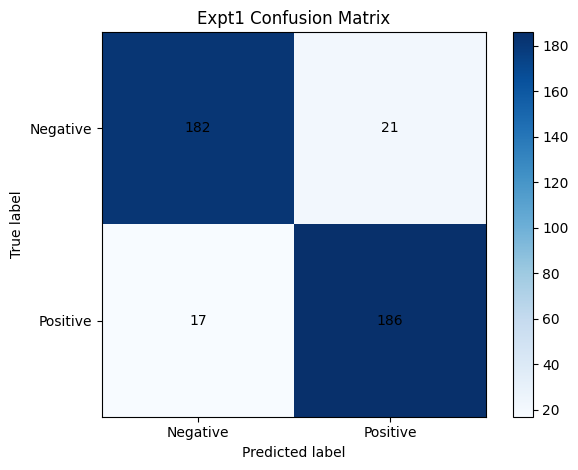

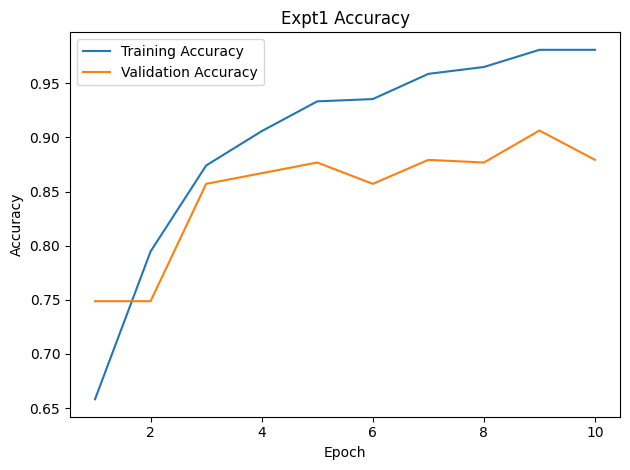

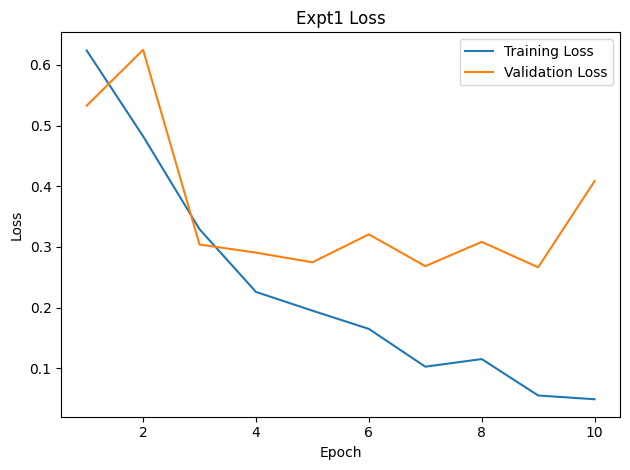

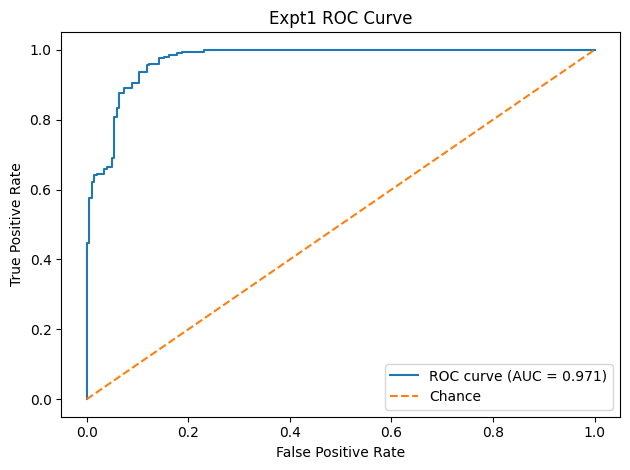

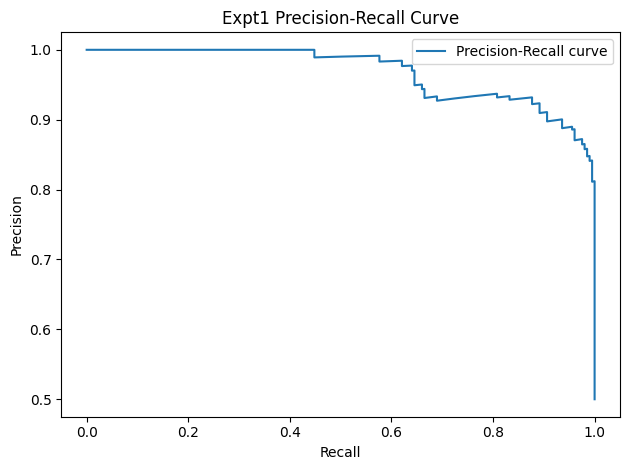


================= Expt2: Dense128 x 64 =================
Epoch 1/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1290s 4s/step - accuracy: 0.9323 - loss: 0.1899 - val_accuracy: 0.8990 - val_loss: 0.2330
Epoch 2/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1124s 4s/step - accuracy: 0.9714 - loss: 0.1014 - val_accuracy: 0.9015 - val_loss: 0.2325
Epoch 3/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1128s 4s/step - accuracy: 0.9799 - loss: 0.0599 - val_accuracy: 0.8571 - val_loss: 0.6632
Epoch 4/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1129s 4s/step - accuracy: 0.9651 - loss: 0.1333 - val_accuracy: 0.9089 - val_loss: 0.3912
Epoch 5/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1130s 4s/step - accuracy: 0.9852 - loss: 0.0485 - val_accuracy: 0.8793 - val_loss: 0.3579
Epoch 6/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1136s 4s/step - accuracy: 0.9746 - loss: 0.0914 - val_accuracy: 0.8892 - val_loss: 0.2499
Epoch 7/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1124s 4s/step - accuracy: 0.9894 - loss: 0.0250 - val_accuracy: 0.9286 - val_loss: 0.2802
13/13 ━━━━━━━━━━━━━━━━━━━━ 130s 

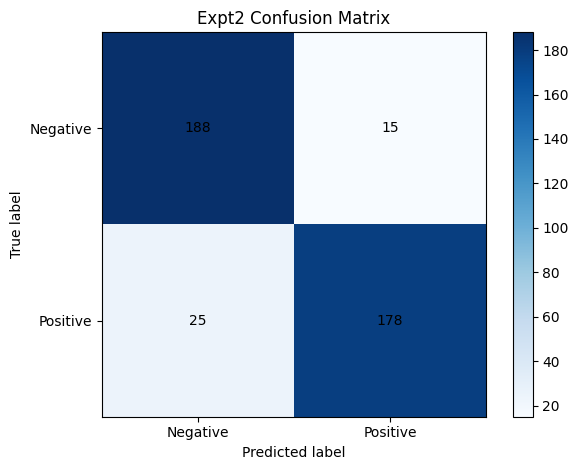

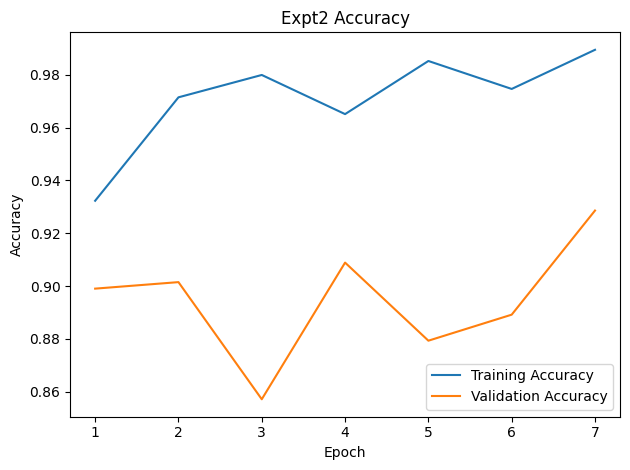

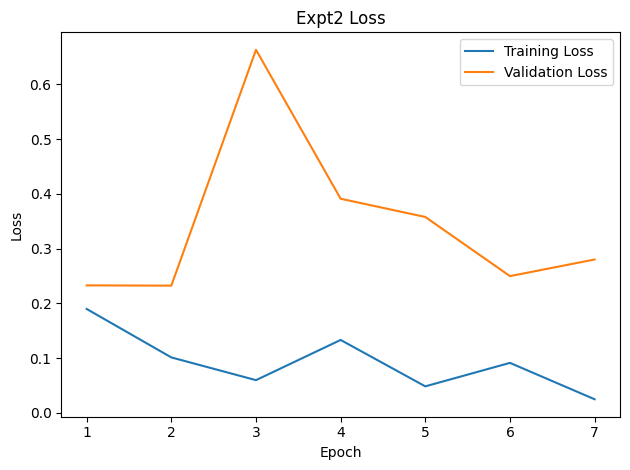

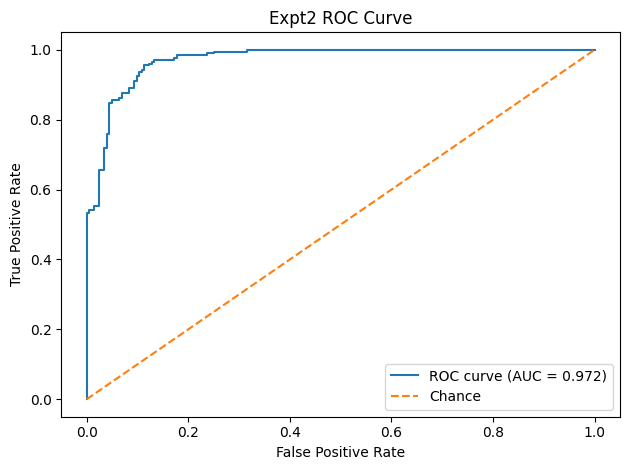

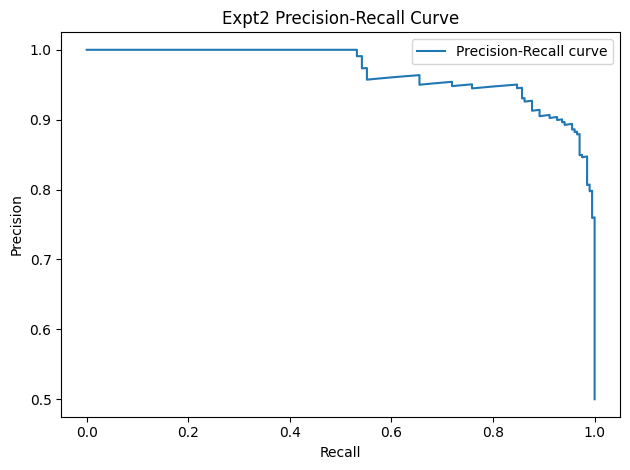


================= Expt3: Dense64 x 8 =================
Epoch 1/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1406s 4s/step - accuracy: 0.8772 - loss: 0.3262 - val_accuracy: 0.8916 - val_loss: 0.2393
Epoch 2/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1385s 4s/step - accuracy: 0.9513 - loss: 0.1580 - val_accuracy: 0.9138 - val_loss: 0.3913
Epoch 3/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1233s 4s/step - accuracy: 0.9280 - loss: 0.1957 - val_accuracy: 0.9015 - val_loss: 0.2715
Epoch 4/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1309s 4s/step - accuracy: 0.9376 - loss: 0.2178 - val_accuracy: 0.8424 - val_loss: 0.2987
Epoch 5/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1117s 4s/step - accuracy: 0.9460 - loss: 0.1513 - val_accuracy: 0.9113 - val_loss: 0.2885
13/13 ━━━━━━━━━━━━━━━━━━━━ 126s 8s/step

Expt3 Confusion Matrix:
 [[175  28]
 [ 16 187]]
              precision    recall  f1-score   support

           0       0.92      0.86      0.89       203
           1       0.87      0.92      0.89       203

    accuracy                           0.

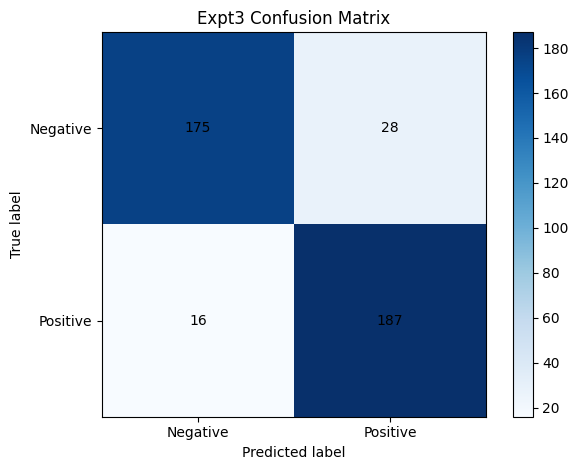

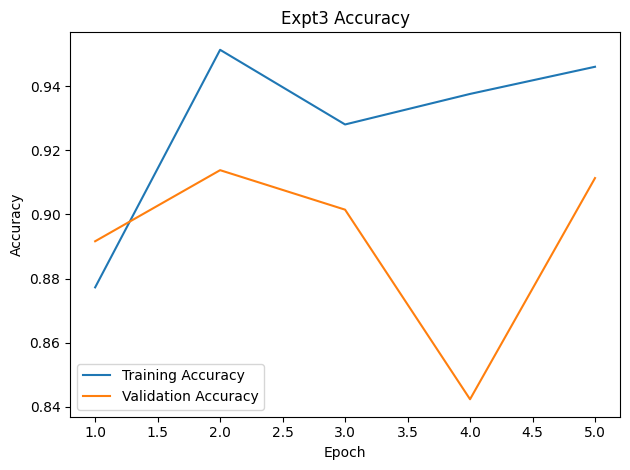

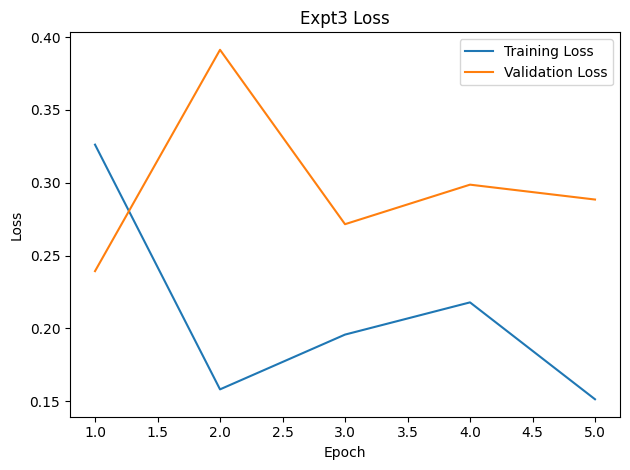

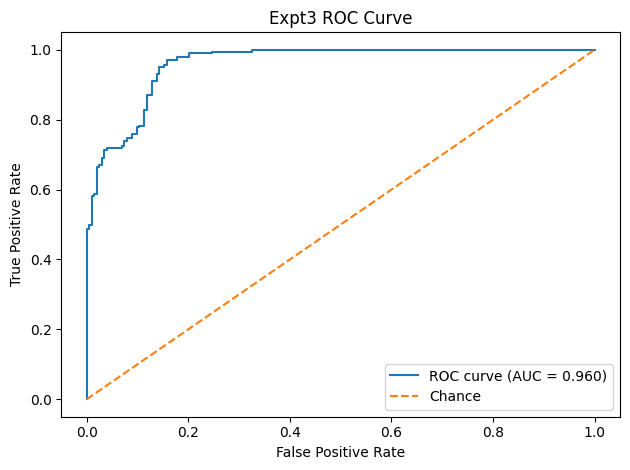

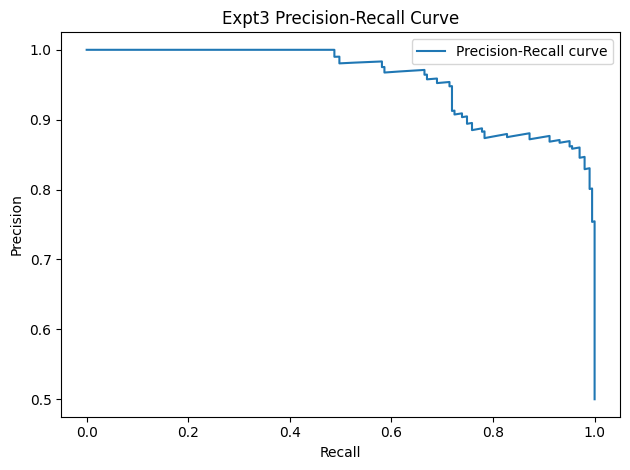

In [ ]:
# 2 DENSE LAYERS EXPERIMENT LOOP
dense_combinations = [(512,256), (128,64), (64,8)]
expt_names = ['Expt1', 'Expt2', 'Expt3']
experiment_results = []

from sklearn.metrics import f1_score

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

best_score = -1   # now this will store best ROC-AUC
best_units = None
best_model = None

for i, (units1, units2) in enumerate(dense_combinations):

    print(f"\n================= {expt_names[i]}: Dense{units1} x {units2} =================")

    # Input layer
    input_layer = Input(shape=(NUM_FRAMES, IMAGE_HEIGHT, IMAGE_WIDTH, 3))

    # CNN feature extraction
    inception_td = TimeDistributed(feature_extractor)(input_layer)

    # GRU layers
    gru_1 = GRU(512, return_sequences=False)(inception_td)
    dropout_1 = Dropout(0.5)(gru_1)

    # First Dense layer
    dense_1 = Dense(units1, activation='relu')(dropout_1)
    dropout_2 = Dropout(0.5)(dense_1)

    # Second Dense layer
    dense_2 = Dense(units2, activation='relu')(dropout_2)
    dropout_3 = Dropout(0.5)(dense_2)

    # Output layer
    output_layer = Dense(num_classes, activation='sigmoid')(dropout_3)

    # Model
    model = Model(inputs=input_layer, outputs=output_layer)

    model.compile(loss='categorical_crossentropy', optimizer=Nadam(1e-4), metrics=['accuracy'])

    # Train
    history = model.fit(
        X_train, y_train_oh,
        validation_data=(X_val, y_val_oh),
        epochs= 10, #15
        batch_size=3,
        class_weight=class_weights,
        callbacks=[early_stopping],
        verbose=1
    )

    # Evaluation
    loss, acc = model.evaluate(X_val, y_val_oh, verbose=0)

    y_pred_prob = model.predict(X_val)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_val_oh, axis=1)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n{expt_names[i]} Confusion Matrix:\n", cm)
    print(classification_report(y_true, y_pred))

    # Plot confusion matrix
    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(f'{expt_names[i]} Confusion Matrix')
    plt.colorbar()
    plt.xlabel('Predicted label')
    plt.ylabel('True label')

    ticks = np.arange(2)
    plt.xticks(ticks, ['Negative','Positive'])
    plt.yticks(ticks, ['Negative','Positive'])

    for i_cm in range(cm.shape[0]):
        for j_cm in range(cm.shape[1]):
            plt.text(j_cm, i_cm, cm[i_cm, j_cm], ha='center', va='center')

    plt.tight_layout()
    plt.show()

    # Training charts
    epochs_range = range(1, len(history.history['accuracy']) + 1)

    # Accuracy
    plt.figure()
    plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy')
    plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{expt_names[i]} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Loss
    plt.figure()
    plt.plot(epochs_range, history.history['loss'], label='Training Loss')
    plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss')
    plt.title(f'{expt_names[i]} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob[:,1])
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0,1],[0,1],'--', label='Chance')
    plt.title(f'{expt_names[i]} ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Precision-Recall curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_pred_prob[:,1])

    plt.figure()
    plt.plot(recall_vals, precision_vals, label='Precision-Recall curve')
    plt.title(f'{expt_names[i]} Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Compute F1-score
    f1_val = f1_score(y_true, y_pred)


    # Use ROC-AUC for best model selection
    if roc_auc > best_score:
        best_score = roc_auc
        best_units = f"{units1}x{units2}"
        best_model = model


    # Store experiment metrics
    experiment_results.append({
        'Experiment': expt_names[i],
        'Dense Layer 1': units1,
        'Dense Layer 2': units2,
        'Val Loss': loss,
        'Val Accuracy': acc,
        'Accuracy': acc,
        'ROC AUC': roc_auc,
        'Precision (avg)': np.mean(precision_vals),
        'Recall (avg)': np.mean(recall_vals),
        'F1 Score': f1_val
    })

In [ ]:
print("Best Dense Units based on ROC-AUC:", best_units)
print("Best ROC-AUC:", best_score)

Best Dense Units based on ROC-AUC: 128x64
Best ROC-AUC: 0.9715353442209226


In [ ]:
# EXPERIMENT RESULTS TABLE
df_results = pd.DataFrame(experiment_results)

# Arrange experiments from highest dense units (1024) to lowest (64)
df_results = df_results.sort_values('Dense Layer 1', ascending=False)

# Reset index and remove index column
df_results = df_results.reset_index(drop=True)

# Round numeric columns for professional display
df_results = df_results.round({
    'Val Loss': 4,
    'Val Accuracy': 4,
    'Accuracy': 4,
    'ROC AUC': 4,
    'Precision (avg)': 4,
    'Recall (avg)': 4,
    'F1 Score': 4
})

# Display table with professional caption
styled_table = df_results.style.set_caption(
    "Table: Two Dense Layer Experiments (Units = 1024, 512, 256, 128, 64)"
).hide(axis='index')

display(styled_table)

Experiment,Dense Layer 1,Dense Layer 2,Val Loss,Val Accuracy,Accuracy,ROC AUC,Precision (avg),Recall (avg),F1 Score
Expt1,512,256,0.266300,0.906400,0.906400,0.970900,0.828900,0.737400,0.907300
Expt2,128,64,0.232500,0.901500,0.901500,0.971500,0.829800,0.736600,0.899000
Expt3,64,8,0.239300,0.891600,0.891600,0.959700,0.823500,0.730900,0.894700


In [ ]:
# SAVE MODEL & WEIGHTS

print(f"\nBest Dense Units Based on F1, AUC, and Accuracy: {best_units}")

best_model.save(f"Xception3_model_{best_units}.keras")
print("Model saved successfully!")

best_model.save(f"Xception_model_{best_units}.h5")
print("Model saved successfully!")

best_model.save_weights(f"Xception_{best_units}.weights.h5")
print("Model weights saved!")


Best Dense Units Based on F1, AUC, and Accuracy: 128x64


Model saved successfully!
Model saved successfully!
Model weights saved!


Saving/cpying weights to drive

In [ ]:
!cp /content/Xception_model_128x64.h5 "/content/drive/MyDrive/Colab Notebooks_videoAnalytics/Xception_Best_Model_Weights/two_dense_layers/"

In [ ]:
!cp /content/Xception3_model_128x64.keras "/content/drive/MyDrive/Colab Notebooks_videoAnalytics/Xception_Best_Model_Weights/two_dense_layers"

In [ ]:
!cp /content/Xception_128x64.weights.h5 "/content/drive/MyDrive/Colab Notebooks_videoAnalytics/Xception_Best_Model_Weights/two_dense_layers/"

In [ ]:
#cjheck contents in the folder containing weights
!ls "/content/drive/MyDrive/Colab Notebooks_videoAnalytics/Xception_Best_Model_Weights/two_dense_layers/"

Xception_128x64.weights.h5    Xception_model_128x64.h5
Xception3_model_128x64.keras
